<a href="https://colab.research.google.com/github/parthnijh/intro-to-pytorch/blob/main/Pytorch_Neural_Network.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import torch
import torch.nn as nn
torch.manual_seed(42)

In [2]:
df=pd.read_csv("/content/drive/MyDrive/fmnist_small.csv")
df

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,9,0,0,0,0,0,0,0,0,0,...,0,7,0,50,205,196,213,165,0,0
1,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,1,0,0,0,...,142,142,142,21,0,3,0,0,0,0
3,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,8,0,0,0,0,0,0,0,0,0,...,213,203,174,151,188,10,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5995,1,0,0,0,0,0,0,0,0,0,...,69,12,0,0,0,0,0,0,0,0
5996,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5997,8,0,0,0,0,0,0,0,0,0,...,39,47,2,0,0,29,0,0,0,0
5998,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


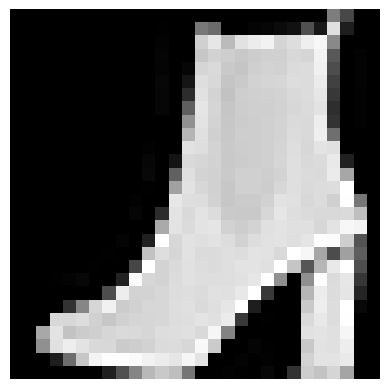

In [3]:
import matplotlib.pyplot as plt

label = df.iloc[0, 0]        # first column
image = df.iloc[0, 1:].values  # remaining 784 pixels
image=image.reshape(28,28)


plt.imshow(image, cmap="gray")

plt.axis("off")
plt.show()

In [4]:
X=df.iloc[:,1:].values
y=df.iloc[:,0].values


In [5]:

from sklearn.model_selection import train_test_split
Xtrain,Xtest,ytrain,ytest=train_test_split(X,y,test_size=0.2)

In [6]:
Xtrain= Xtrain/255.0

Xtest=Xtest/255.0

In [7]:
from torch.utils.data import Dataset,DataLoader
class CustomDataset(Dataset):
  def __init__(self,features,labels):
    self.features=torch.tensor(features,dtype=torch.float32)
    self.labels=torch.tensor(labels,dtype=torch.long)



  def __len__(self):
    return len(self.features)


  def __getitem__(self,idx):
    return self.features[idx],self.labels[idx]



In [8]:
train_dataset=CustomDataset(Xtrain,ytrain)
len(train_dataset)

4800

In [9]:
test_dataset=CustomDataset(Xtest,ytest)


In [10]:
train_loader=DataLoader(train_dataset,batch_size=32,shuffle=True)
test_loader=DataLoader(test_dataset,batch_size=32,shuffle=False)

In [11]:
class MyNN(nn.Module):
  def __init__(self,num_features):
    super().__init__()
    self.model=nn.Sequential(
        nn.Linear(num_features,128),
        nn.ReLU(),
        nn.Linear(128,64),
        nn.ReLU(),
        nn.Linear(64,10)


    )


  def forward(self,x):
    return self.model(x)





In [12]:
epochs=100
learning_rate=0.1


In [13]:
model=MyNN(Xtrain.shape[1])
criterion=nn.CrossEntropyLoss()
optimizer=torch.optim.SGD(model.parameters(),lr=learning_rate)


In [19]:
for data in train_loader:
  print(data)

[tensor([[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        ...,
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000,  ..., 0.5255, 0.1333, 0.0000],
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]]), tensor([3, 2, 5, 5, 2, 6, 7, 2, 4, 2, 7, 9, 7, 3, 6, 8, 1, 6, 1, 7, 0, 3, 1, 0,
        4, 5, 6, 4, 1, 9, 4, 8])]
[tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]]), tensor([8, 4, 9, 1, 4, 9, 9, 0, 8, 5, 9, 5, 9, 2, 6, 6, 4, 7, 0, 7, 2, 3, 6, 6,
        6, 3, 0, 7, 4, 4, 6, 9])]
[tensor([[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.00

In [20]:
#training loop
for epoch in range(epochs):
  totalloss=0
  for batch_features,batch_labels in train_loader:
    #forward pass
    out=model(batch_features)
    #calculate loss
    loss=criterion(out,batch_labels)
    #back pass
    optimizer.zero_grad()
    loss.backward()
    #update grads
    optimizer.step()

    totalloss=totalloss+loss.item()
  avgloss=totalloss/len(train_loader)
  print(f"Epoch{epoch+1} Loss{avgloss}")

Epoch1 Loss1.3299100045363108
Epoch2 Loss0.7771119469404221
Epoch3 Loss0.6578780317306518
Epoch4 Loss0.5804127312699954
Epoch5 Loss0.5319913893938064
Epoch6 Loss0.49393964737653734
Epoch7 Loss0.4690497634808222
Epoch8 Loss0.44772398193677265
Epoch9 Loss0.4204965841770172
Epoch10 Loss0.41644029011329015
Epoch11 Loss0.3848559196293354
Epoch12 Loss0.37505967676639557
Epoch13 Loss0.3556198114653428
Epoch14 Loss0.3522683160503705
Epoch15 Loss0.34287775521477065
Epoch16 Loss0.32081098303198813
Epoch17 Loss0.3027466683089733
Epoch18 Loss0.30009581675132113
Epoch19 Loss0.2841232454280059
Epoch20 Loss0.28029205307364463
Epoch21 Loss0.2708557918667793
Epoch22 Loss0.26202627980460724
Epoch23 Loss0.249719683577617
Epoch24 Loss0.23502601094543935
Epoch25 Loss0.23729085485140483
Epoch26 Loss0.2285697863002618
Epoch27 Loss0.2230861193438371
Epoch28 Loss0.21928603384643794
Epoch29 Loss0.20850783191621303
Epoch30 Loss0.196779115870595
Epoch31 Loss0.18807227797806264
Epoch32 Loss0.19027976072082917
Epoc